In [1]:
"""
Example of application of MCMC to simple parameter estimation problem
Adapted from Parameter Estimation and Inverse Problems, 2nd edition, 2011
Example 11.4 by R. Aster, B. Borchers, C. Thurber

For the DTU MSc class 30760 Inverse problems and Machine Learning in Earth and Space Sciences
(ported to python by E.Y.H. Lippert 07.04.2019, Minor modifications by C. Finlay)
"""

%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib as mpl
import numpy.typing as npt
from dataclasses import dataclass, field
from tqdm.auto import trange, tqdm

In [2]:
def fun(m, x):
    """
    Computes the forward problem y=p(1)*exp(p(2)*x)+p(3)*x*exp(p(4)*x)
    """
    return m[0] * np.exp(m[1] * x) + m[2] * x * np.exp(m[3] * x)


def logprior(m, m_bounds=None):
    if m_bounds is not None:
        m_bounds = m_bounds
    else:
        m_bounds = np.array([[-1.0, 2.0], [-0.9, 0.9], [-1, 2], [-0.9, 0.9]])

    condition = np.logical_and.reduce(
        (
            m[0] >= m_bounds[0][0],
            m[0] <= m_bounds[0][1],
            m[1] >= m_bounds[1][0],
            m[1] <= m_bounds[1][1],
            m[2] >= m_bounds[2][0],
            m[2] <= m_bounds[2][1],
            m[3] >= m_bounds[3][0],
            m[3] <= m_bounds[3][1],
        )
    )

    if condition == True:
        lp = 0
    else:
        lp = -np.inf

    return lp


def loglikelihood(m, x, y, sigma):
    """
    Log likelihood
    """

    # Compute the standardized residuals.
    fvec = (y - fun(m, x)) / sigma

    # The log likelihood is (-1/2)*sum(fvec(i)^2,i=1..n);
    return (-1 / 2) * np.sum(fvec**2)


def logproposal(x, y, step):
    """
    For this problem, we'll use a multivariate normal generator, with
    standard deviations specified by the vector step.
    """
    return (-1 / 2) * np.sum((x - y) ** 2 / step**2)


def generate(x, step):
    """
    For this problem, we'll use a multivariate normal generator, with
    standard deviations specified by the vector step.
    """
    return x + step * np.random.randn(4)


def calc_corr(x, laglen):
    """
    Returns the first laglen elements of the circular (normalized) correlation of the column vector x
    """

    c = np.zeros((laglen + 1))

    # compute standard deviation
    x = x - np.mean(x)

    # compute variance
    c[0] = x.dot(x)

    # compute circular correlations
    for i in range(1, laglen + 2):
        c[i - 1] = x.dot(np.roll(x, i - 1))

    # normalise to values in -1,1
    c = c / c[0]

    return np.hstack((np.flipud(c[1::]), c))

In [3]:
# %%
# set random seed, in order to reproduce results
np.random.seed(1)

# Generate the test data set and add noise
x = np.arange(1, 7.25, 0.25)
true_model = [1.0, -0.5, 1.0, -0.75]

# computes the forward problem y=p(1)*exp(p(2)*x)+p(3)*x*exp(p(4)*x)
y_true = fun(m=true_model, x=x)


# Add noise to generate synthetic data
noise_scale = 0.01
sigma = noise_scale * np.ones(y_true.size)
y = y_true + sigma * np.random.randn(y_true.size)


In [4]:
# %% set the MCMC parameters
# number of steps of algorithm
N = 410000

# Multivariate normal (MVN) step size
step = 0.005 * np.ones(4)

# number of skips to reduce autocorrelation of models
skip = 1000

# burn-in steps
burn_in = 10000

In [5]:
# We assume flat (uniform) priors here
m_boundaries = np.array([[0, 2.0], [-1.0, 0], [0, 2.0], [-1.0, 0]])

# Initialise model
m0 = []
for m_inbounds in m_boundaries:
    m0.append(np.random.uniform(low=m_inbounds[0], high=m_inbounds[1], size=1))

m0 = np.array(m0).reshape(
    -1,
)
print("m0:", m0)

m0: [ 0.20645201 -0.55210647  1.81719101 -0.70638585]


In [6]:
# Using this cell forces same starting random numbers as in matlab case
m0 = np.array([0.9003, -0.5377, 0.2137, -0.0280])
m_boundaries = [(0, 2.0), (-1.0, 0), (0, 2.0), (-1.0, 0)]

y = np.array(
    [
        1.0746,
        1.0081,
        0.9606,
        0.8907,
        0.8027,
        0.7528,
        0.6818,
        0.6021,
        0.5426,
        0.4826,
        0.4254,
        0.3858,
        0.3286,
        0.3167,
        0.2580,
        0.2289,
        0.2103,
        0.1754,
        0.1519,
        0.1251,
        0.1194,
        0.0881,
        0.0955,
        0.0932,
        0.0600,
    ]
)

In [7]:
#### The Metropolis-Hastings Sampler (Algorithm 11.2 in Aster et al.)

# Figure out initial size information
n = len(m0)

# Initialize
m_out = np.zeros((n, N))
m_out[:, 0] = m0.squeeze()
current_model = m0
l_MAP = -np.inf
m_MAP = current_model
n_acc = 0

# Step through model space
for i in trange(1, N):
    ### 1. Generate a candidate model from the previous model using the MVN distribution with chosen step size
    candidate_model = generate(x=current_model, step=step)

    ### 2. Compute log(alpha)
    # Comments follow Aster et al. notation, implementation variables do not!!!
    ## Estimate local balance
    # s = (q(y)r(y,x))/(q(x)r(x,y))
    # candidate posterior distribution q(m) is proportional to p(m)*f(d|m), so
    # s = (p(y)*f(d|m)*r(y,x))/(p(x)*f(d|m)*r(x,y))

    ## Compute log of distributions/likelihood
    # p(y)
    lp_candidate = logprior(candidate_model, m_bounds=m_boundaries)
    # f(d|y)
    ll_candidate = loglikelihood(m=candidate_model, x=x, y=y, sigma=sigma)
    # r(y,x)
    lr_1 = logproposal(x=candidate_model, y=current_model, step=step)

    # p(x)
    lp_current = logprior(current_model, m_bounds=m_boundaries)
    # f(d|y)
    ll_current = loglikelihood(current_model, x=x, y=y, sigma=sigma)
    # r(x,y)
    lr_2 = logproposal(x=current_model, y=candidate_model, step=step)

    ##########################################
    # KEY STEPS: Evaluate the logarithm of s
    # As log(i*j) = log(i) + log(j) and log(i/j) = log(i) - log(j)
    s = lp_candidate + ll_candidate + lr_1 - lp_current - ll_current - lr_2

    # Take the minimum of s and 0 (log(1.0)=0.0)
    log_alpha = np.fmin(0, s)

    ### 3. Generate a U(0,1) (uniform distribution between 0 and 1) random number and take its logarithm.
    log_t = np.log(np.random.rand())

    ### 4. Accept or reject the step
    if log_t < log_alpha:
        # Accept the step
        current_model = candidate_model
        n_acc += 1

        # Update the MAP solution if this one is better
        if lp_candidate + ll_candidate > l_MAP:
            l_MAP = lp_candidate + ll_candidate
            m_MAP = candidate_model

    else:
        # Reject the step
        pass

    ##########################################

    # Record the result
    m_out[:, i] = current_model.squeeze()
    p_acc = n_acc / N

print("Acceptance rate, P_acc =", p_acc)

# down-sample results to reduce correlation and exclude burn in period
m_reduced = m_out[:, burn_in - 1 :: skip]

# estimate of the MAP model
print("MAP model:  ", m_MAP[:], "\nTrue model: ", true_model)

  0%|          | 0/409999 [00:00<?, ?it/s]

Acceptance rate, P_acc = 0.39542926829268293
MAP model:   [ 0.98646884 -0.55445947  1.03572099 -0.72164433] 
True model:  [1.0, -0.5, 1.0, -0.75]


In [8]:
@dataclass
class ExperimentResult:
    x: npt.NDArray
    y: npt.NDArray
    sigma: npt.NDArray
    step: int

    m_boundaries: npt.NDArray
    m_out: npt.NDArray
    m_reduced: npt.NDArray
    m_MAP: npt.NDArray
    p_acc: float
    true_model: npt.NDArray

    pvars: list[str] = field(
        default_factory=lambda: [r"$m_1$", r"$m_2$", r"$m_3$", r"$m_4$"]
    )

    def get_percentiles(self, percentiles=[2.5, 97.5]):
        m_percentiles = np.empty((len(percentiles), self.m_reduced.shape[0]))
        for i in range(self.m_reduced.shape[0]):
            m_sorted = np.sort(self.m_reduced[i, :])
            for j, p in enumerate(percentiles):
                m_percentiles[j, i] = m_sorted[
                    np.round(p / 100 * self.m_reduced.shape[1]).astype(int) - 1
                ]
        return m_percentiles

    def print_summary(self):
        print("MAP model:  ", self.m_MAP[:], "\nTrue model: ", self.true_model)
        print("Acceptance rate, P_acc =", self.p_acc)

        m_025, m_975 = self.get_percentiles([2.5, 97.5])
        for i in range(4):
            m_sorted = np.sort(self.m_reduced[i, :])
            m_025[i] = m_sorted[
                np.round(2.5 / 100 * self.m_reduced.shape[1]).astype(int) - 1
            ]
            m_975[i] = m_sorted[
                np.round(97.5 / 100 * self.m_reduced.shape[1]).astype(int) - 1
            ]
            print(
                "95% confidence interval for m_{:.0f} is [{:.2f}, {:.2f}]".format(
                    i + 1, m_025[i], m_975[i]
                )
            )

    def plot_results(self):
        m_025, m_975 = self.get_percentiles([2.5, 97.5])

        ## Plot a scatter plot and histogram of the posterior distribution
        fig = plt.figure(figsize=(9, 9))
        gs = fig.add_gridspec(4, 4)
        for j in np.arange(0, 4):
            for i in np.arange(0, 4):
                ax = fig.add_subplot(gs[j, i])
                # plot histograms along the diagonal
                if i == j:
                    ax.hist(self.m_reduced[i, :], bins=21)
                    ax.yaxis.set_ticks([])
                else:
                    # scatter of posterior sample model param correlation
                    ax.scatter(
                        self.m_reduced[i, :],
                        self.m_reduced[j, :],
                        s=0.1,
                        color=(0.6, 0.6, 0.6),
                    )
                    # plot true model value when available
                    if self.true_model is not None:
                        ax.plot(
                            self.true_model[i],
                            self.true_model[j],
                            color="k",
                            marker=".",
                            markersize=10,
                        )
                    # plot MAP estimate
                    ax.plot(
                        self.m_MAP[i],
                        self.m_MAP[j],
                        color="orange",
                        marker="o",
                        markersize=10,
                        mfc="none",
                        markeredgewidth=2,
                    )
                    # create bounding box from 2.5% and 97.5% quantiles
                    box = patches.Rectangle(
                        xy=(m_025[i], m_025[j]),
                        width=abs(m_975[i] - m_025[i]),
                        height=abs(m_975[j] - m_025[j]),
                        linewidth=1,
                        edgecolor="k",
                        facecolor="none",
                    )
                    ax.add_patch(box)

                # labels
                if i == 0:
                    ax.set_ylabel(self.pvars[j])
                if j == 3:
                    ax.set_xlabel(self.pvars[i])

        # Adjust plot positions
        fig.subplots_adjust(
            left=0.1, bottom=0.1, right=0.9, top=0.9, wspace=0.4, hspace=0.4
        )
        return fig

    def plot_history(self):
        # %% Plot parameter sample histories
        fig, ax = plt.subplots(4, 1, figsize=(9, 9))
        for i in range(4):
            # plt.subplot(4, 1, i + 1)
            ax[i].axhline(self.true_model[i], color="gold", label="True value")
            ax[i].plot(
                self.m_reduced[i, :],
                color="violet",
                marker="+",
                linestyle="",
                label="Sample estimates",
            )
            ax[i].set_ylabel(self.pvars[i])
            if i == 3:
                plt.legend(bbox_to_anchor=(0.3, 5.15))
                plt.xlabel("Number of samples")
            else:
                ax[i].xaxis.set_ticklabels([])
        return fig

    def plot_autocorrelation(self, laglen=50):
        # %% Plot parameter correlations
        laglen = 50
        lags = np.arange(-laglen, laglen + 1, 1)

        fig, ax = plt.subplots(4, 1, figsize=(9, 9))
        for i in range(4):
            # calculate parameter autocorrelation
            corr_tmp = calc_corr(x=self.m_reduced[i, :], laglen=laglen)
            ax[i].axhline(0, color="darkseagreen", label="No correlation")
            ax[i].plot(
                lags[laglen::],
                corr_tmp[laglen::],
                linestyle="",
                marker="1",
                color="coral",
                label="Sample correlation",
            )
            ax[i].set_ylabel("A({})".format(self.pvars[i]))

            # set fine grid lines
            ax[i].get_xaxis().set_minor_locator(mpl.ticker.AutoMinorLocator())
            ax[i].get_yaxis().set_minor_locator(mpl.ticker.AutoMinorLocator())
            ax[i].grid(visible=True, which="major", color="w", linewidth=1.0)
            ax[i].grid(visible=True, which="minor", color="w", linewidth=0.5)
            ax[i].tick_params(which="both", bottom=True)

            if i == 3:
                plt.legend(bbox_to_anchor=(0.3, 5.15))
                plt.xlabel("Lag")
            else:
                ax[i].xaxis.set_ticklabels([])

        return fig

    def plot_likelihood_pdf(self):
        # %% Examine the likelihood probability distribution
        loglike = np.empty(self.m_reduced.shape[1])
        for i in range(self.m_reduced.shape[1]):
            loglike[i] = loglikelihood(
                m=self.m_reduced[:, i], x=self.x, y=self.y, sigma=self.sigma
            ) + logprior(m=self.m_reduced[:, i], m_bounds=self.m_boundaries)

        m_MAP_likelihood = loglikelihood(
            self.m_MAP, x=self.x, y=self.y, sigma=self.sigma
        ) + logprior(self.m_MAP, m_bounds=self.m_boundaries)

        fig, ax = plt.subplots(1, 1, figsize=(9, 9))
        plt.hist(loglike, bins=30)
        ax.axvline(m_MAP_likelihood, color="grey", linestyle="--", label="m_MAP")

        m_true_likelihood = loglikelihood(
            self.true_model, x=self.x, y=self.y, sigma=self.sigma
        ) + logprior(self.true_model, m_bounds=self.m_boundaries)
        ax.axvline(m_true_likelihood, color="black", linestyle=":", label="m_true")

        ax.set_xlabel("log likelihood")
        ax.set_ylabel("N")
        plt.legend()

        return fig


class Experiment:
    def __init__(self, x, y, sigma, step, m_boundaries, true_model):
        self.x = x
        self.y = y
        self.sigma = sigma
        self.step = step
        self.m_boundaries = m_boundaries
        self.true_model = true_model

    def run(
        self,
        m0: npt.NDArray,
        N=410000,
        N_burn_in: int = 10000,
        reducer: slice = slice(None, None, 1000),
    ):
        assert N > 1
        n = len(m0)

        # Initialize
        m_out = np.zeros((n, N))
        m_out[:, 0] = m0.squeeze()
        current_model = m0
        l_MAP = -np.inf
        m_MAP = current_model
        n_acc = 0

        # Step through model space
        for i in trange(1, N):
            ### 1. Generate a candidate model from the previous model using the MVN distribution with chosen step size
            candidate_model = generate(x=current_model, step=self.step)

            ### 2. Compute log(alpha)
            # Comments follow Aster et al. notation, implementation variables do not!!!
            ## Estimate local balance
            # s = (q(y)r(y,x))/(q(x)r(x,y))
            # candidate posterior distribution q(m) is proportional to p(m)*f(d|m), so
            # s = (p(y)*f(d|m)*r(y,x))/(p(x)*f(d|m)*r(x,y))

            ## Compute log of distributions/likelihood
            # p(y)
            lp_candidate = logprior(candidate_model, m_bounds=self.m_boundaries)
            # f(d|y)
            ll_candidate = loglikelihood(
                m=candidate_model, x=self.x, y=self.y, sigma=self.sigma
            )
            # r(y,x)
            lr_1 = logproposal(x=candidate_model, y=current_model, step=self.step)

            # p(x)
            lp_current = logprior(current_model, m_bounds=self.m_boundaries)
            # f(d|y)
            ll_current = loglikelihood(current_model, x=self.x, y=self.y, sigma=self.sigma)
            # r(x,y)
            lr_2 = logproposal(x=current_model, y=candidate_model, step=self.step)

            ##########################################
            # KEY STEPS: Evaluate the logarithm of s
            # As log(i*j) = log(i) + log(j) and log(i/j) = log(i) - log(j)
            s = lp_candidate + ll_candidate + lr_1 - lp_current - ll_current - lr_2

            # Take the minimum of s and 0 (log(1.0)=0.0)
            log_alpha = np.fmin(0, s)

            ### 3. Generate a U(0,1) (uniform distribution between 0 and 1) random number and take its logarithm.
            log_t = np.log(np.random.rand())

            ### 4. Accept or reject the step
            if log_t < log_alpha:
                # Accept the step
                current_model = candidate_model
                n_acc += 1

                # Update the MAP solution if this one is better
                if lp_candidate + ll_candidate > l_MAP:
                    l_MAP = lp_candidate + ll_candidate
                    m_MAP = candidate_model

            else:
                # Reject the step
                pass

            ##########################################

            # Record the result
            m_out[:, i] = current_model.squeeze()
            p_acc = n_acc / N

        print("Acceptance rate, P_acc =", p_acc)

        # down-sample results to reduce correlation and exclude burn in period
        m_burnt_in = m_out[:, N_burn_in - 1 :]
        m_reduced = m_burnt_in[:, reducer]

        # estimate of the MAP model
        print("MAP model:  ", m_MAP[:])

        return ExperimentResult(
            x=self.x,
            y=self.y,
            sigma=self.sigma,
            m_boundaries=self.m_boundaries,
            step=self.step,
            m_out=m_out,
            m_reduced=m_reduced,
            m_MAP=m_MAP,
            p_acc=p_acc,
            true_model=self.true_model,
        )

In [9]:
m0 = np.array([0.9003, -0.5377, 0.2137, -0.0280])
m_boundaries = [(0, 2.0), (-1.0, 0), (0, 2.0), (-1.0, 0)]

y = np.array(
    [
        1.0746,
        1.0081,
        0.9606,
        0.8907,
        0.8027,
        0.7528,
        0.6818,
        0.6021,
        0.5426,
        0.4826,
        0.4254,
        0.3858,
        0.3286,
        0.3167,
        0.2580,
        0.2289,
        0.2103,
        0.1754,
        0.1519,
        0.1251,
        0.1194,
        0.0881,
        0.0955,
        0.0932,
        0.0600,
    ]
)

experiment = Experiment(x=x, y=y, sigma=sigma, m_boundaries=m_boundaries, step=step, true_model=true_model)
result = experiment.run(m0=m0, N=N, N_burn_in=burn_in, reducer=slice(None, None, skip))

  0%|          | 0/409999 [00:00<?, ?it/s]

Acceptance rate, P_acc = 0.39133658536585364
MAP model:   [ 0.98970878 -0.57319876  1.04878905 -0.71670516]


In [10]:
result.print_summary()

MAP model:   [ 0.98970878 -0.57319876  1.04878905 -0.71670516] 
True model:  [1.0, -0.5, 1.0, -0.75]
Acceptance rate, P_acc = 0.39133658536585364
95% confidence interval for m_1 is [0.86, 1.11]
95% confidence interval for m_2 is [-0.96, -0.44]
95% confidence interval for m_3 is [0.93, 1.39]
95% confidence interval for m_4 is [-0.79, -0.69]


Ellipsis

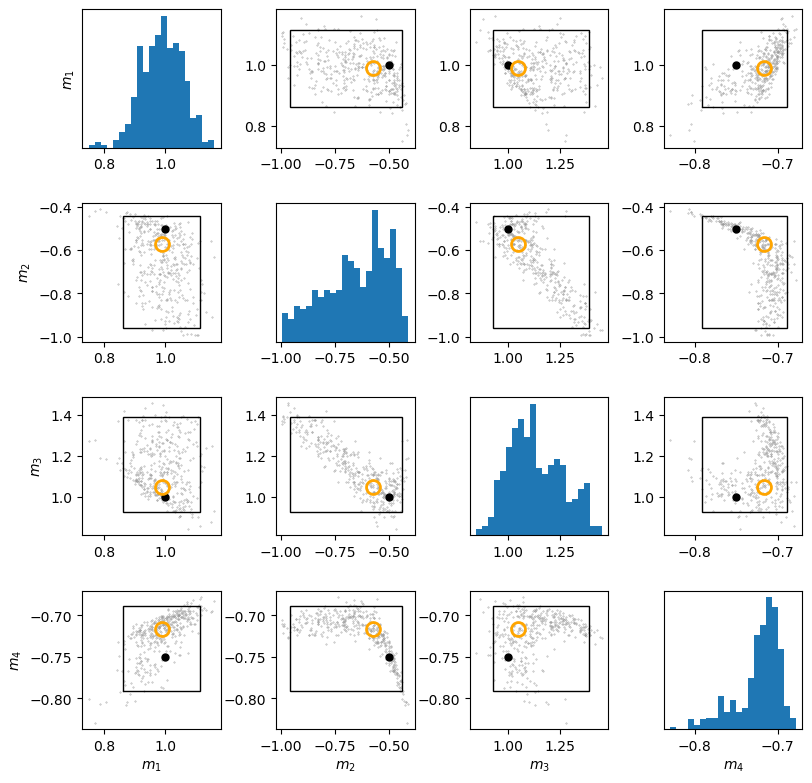

In [11]:
result.plot_results()
...

In [12]:
# estimate the 95% credible intervals
m_025 = np.empty((4,))
m_975 = np.empty((4,))
for i in range(4):
    m_sorted = np.sort(m_reduced[i, :])
    m_025[i] = m_sorted[np.round(2.5 / 100 * m_reduced.shape[1]).astype(int) - 1]
    m_975[i] = m_sorted[np.round(97.5 / 100 * m_reduced.shape[1]).astype(int) - 1]
    print(
        "95% confidence interval for m_{:.0f} is [{:.2f}, {:.2f}]".format(
            i + 1, m_025[i], m_975[i]
        )
    )

95% confidence interval for m_1 is [0.82, 1.09]
95% confidence interval for m_2 is [-0.92, -0.43]
95% confidence interval for m_3 is [0.90, 1.36]
95% confidence interval for m_4 is [-0.80, -0.69]


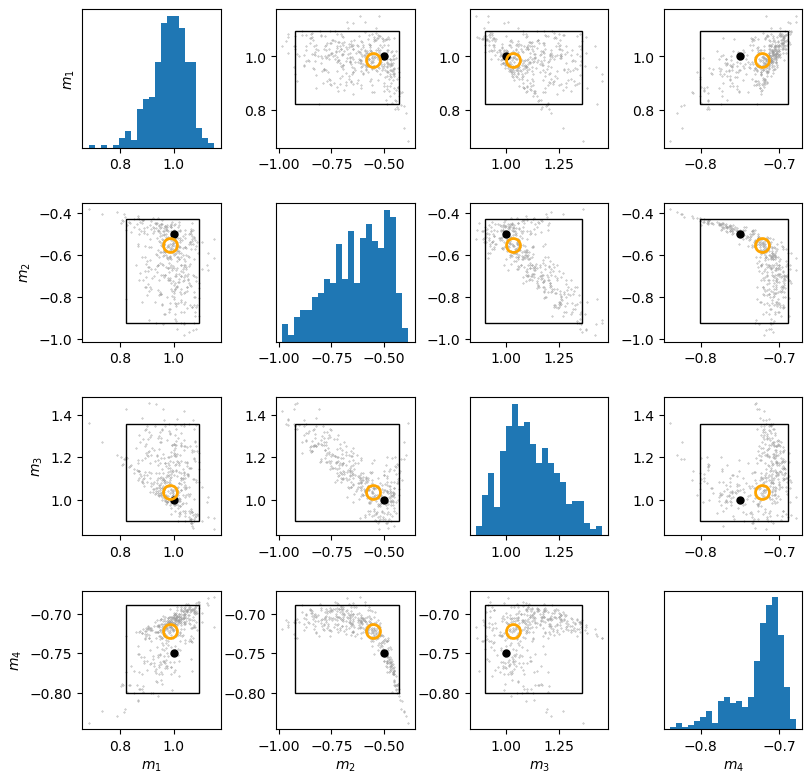

In [13]:
pvars = [r"$m_1$", r"$m_2$", r"$m_3$", r"$m_4$"]

## Plot a scatter plot and histogram of the posterior distribution
fig = plt.figure(figsize=(9,9))
gs = fig.add_gridspec(4, 4)
for j in np.arange(0,4):
    for i in np.arange(0,4):
        ax = fig.add_subplot(gs[j,i])
        # plot histograms along the diagonal
        if i == j:
            ax.hist(m_reduced[i,:], bins = 21)
            ax.yaxis.set_ticks([])
        else:
            # scatter of posterior sample model param correlation
            ax.scatter(m_reduced[i,:],m_reduced[j,:], s=0.1, color=(.6,.6,.6))
            # plot true model value
            ax.plot(true_model[i], true_model[j], color='k', marker='.', markersize=10)
            # plot MAP estimate
            ax.plot(m_MAP[i], m_MAP[j], color='orange', marker='o', markersize=10, mfc='none', markeredgewidth=2)
            # create bounding box from 2.5% and 97.5% quantiles
            box = patches.Rectangle(xy=(m_025[i], m_025[j]), width=abs(m_975[i]-m_025[i]), height=abs(m_975[j]-m_025[j]),
                                    linewidth=1, edgecolor='k', facecolor='none')
            ax.add_patch(box)

        # labels
        if i == 0:
            ax.set_ylabel(pvars[j])
        if j == 3:
            ax.set_xlabel(pvars[i])

# Adjust plot positions
fig.subplots_adjust(left=0.1, bottom=0.1, right=0.9, top=0.9, wspace=0.4, hspace=0.4)
plt.show()

Ellipsis

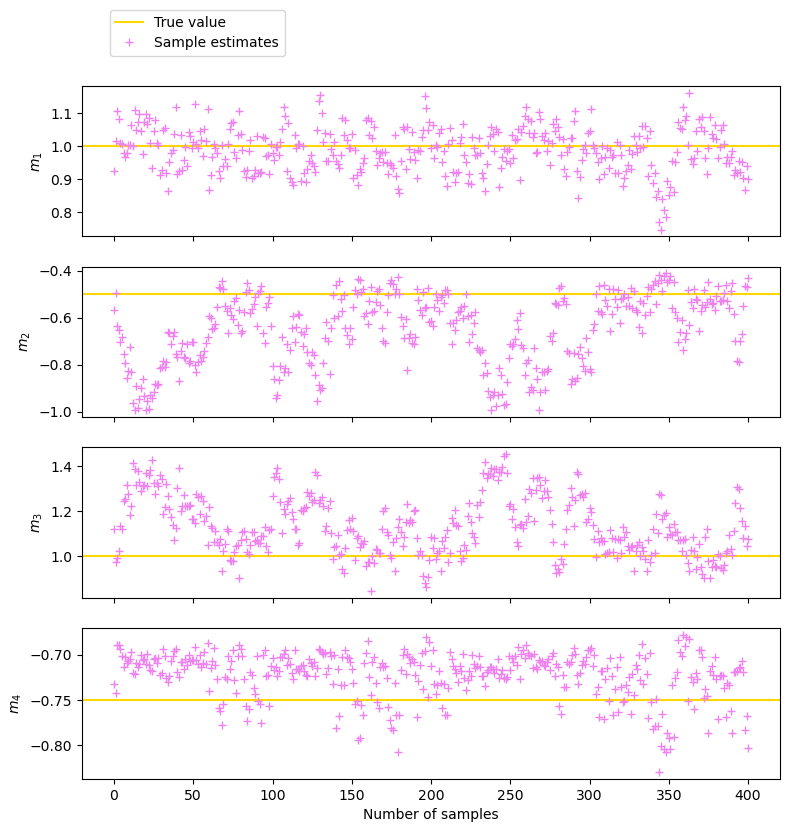

In [14]:
result.plot_history()
...

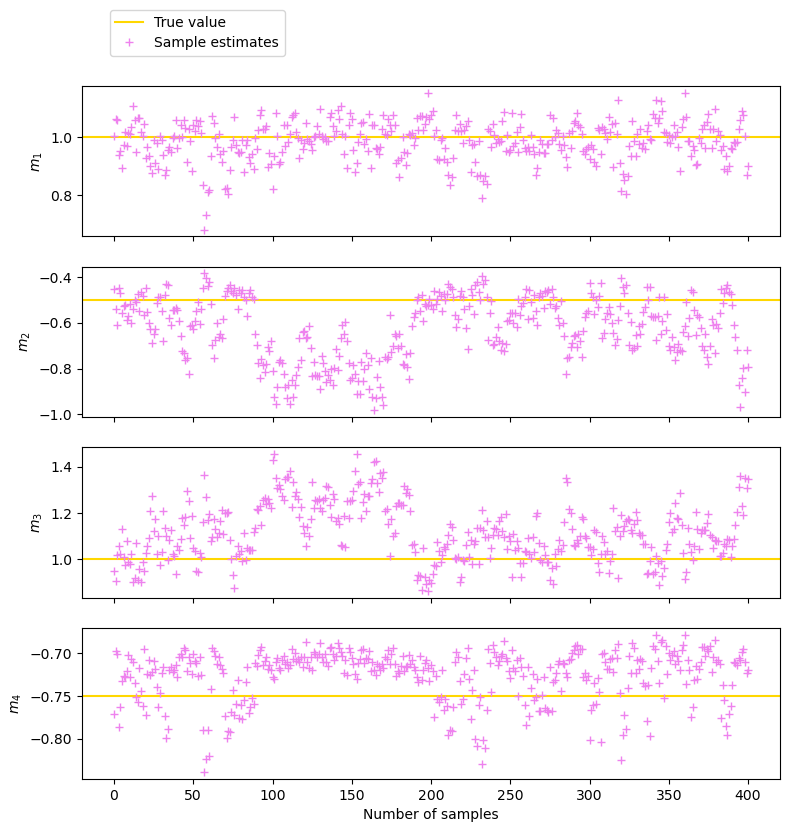

In [15]:
# %% Plot parameter sample histories
fig, ax = plt.subplots(4, 1, figsize=(9, 9))
for i in range(4):
    # plt.subplot(4, 1, i + 1)
    ax[i].axhline(true_model[i], color="gold", label="True value")
    ax[i].plot(
        m_reduced[i, :],
        color="violet",
        marker="+",
        linestyle="",
        label="Sample estimates",
    )
    ax[i].set_ylabel(pvars[i])
    if i == 3:
        plt.legend(bbox_to_anchor=(0.3, 5.15))
        plt.xlabel("Number of samples")
    else:
        ax[i].xaxis.set_ticklabels([])
plt.show()

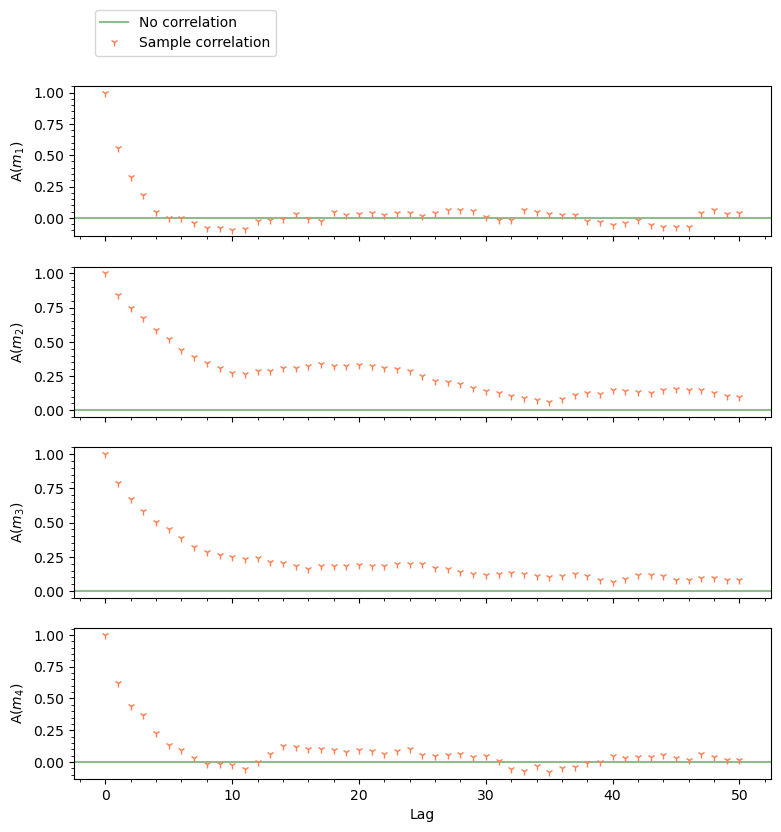

In [16]:
# %% Plot parameter correlations
laglen = 50
lags = np.arange(-laglen, laglen + 1, 1)

fig, ax = plt.subplots(4, 1, figsize=(9, 9))
for i in range(4):
    # calculate parameter autocorrelation
    corr_tmp = calc_corr(x=m_reduced[i, :], laglen=laglen)
    ax[i].axhline(0, color="darkseagreen", label="No correlation")
    ax[i].plot(
        lags[laglen::],
        corr_tmp[laglen::],
        linestyle="",
        marker="1",
        color="coral",
        label="Sample correlation",
    )
    ax[i].set_ylabel("A({})".format(pvars[i]))

    # set fine grid lines
    ax[i].get_xaxis().set_minor_locator(mpl.ticker.AutoMinorLocator())
    ax[i].get_yaxis().set_minor_locator(mpl.ticker.AutoMinorLocator())
    ax[i].grid(visible=True, which="major", color="w", linewidth=1.0)
    ax[i].grid(visible=True, which="minor", color="w", linewidth=0.5)
    ax[i].tick_params(which="both", bottom=True)

    if i == 3:
        plt.legend(bbox_to_anchor=(0.3, 5.15))
        plt.xlabel("Lag")
    else:
        ax[i].xaxis.set_ticklabels([])
plt.show()

Ellipsis

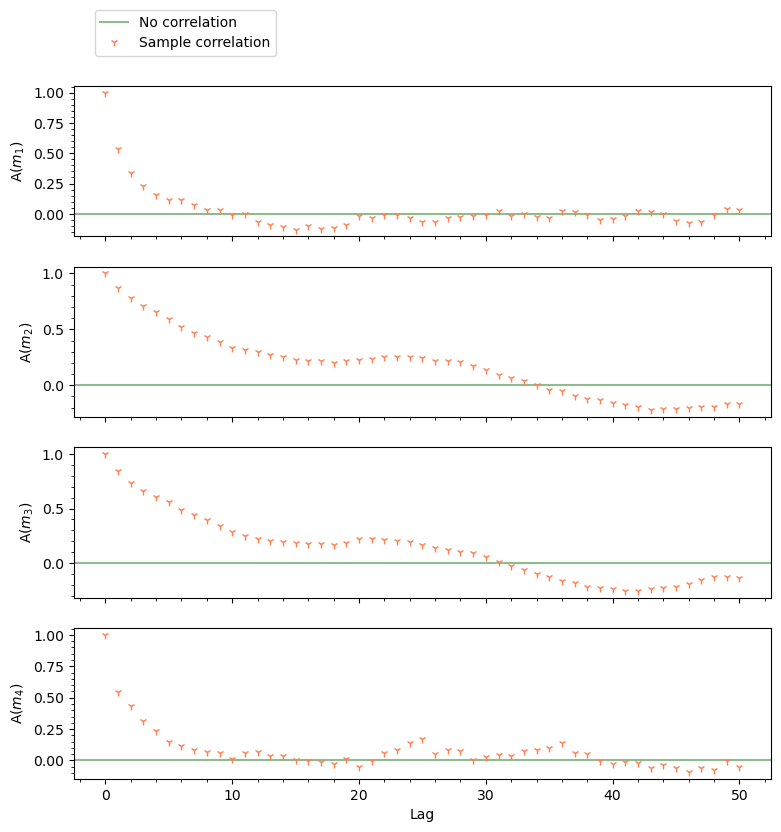

In [17]:
result.plot_autocorrelation()
...

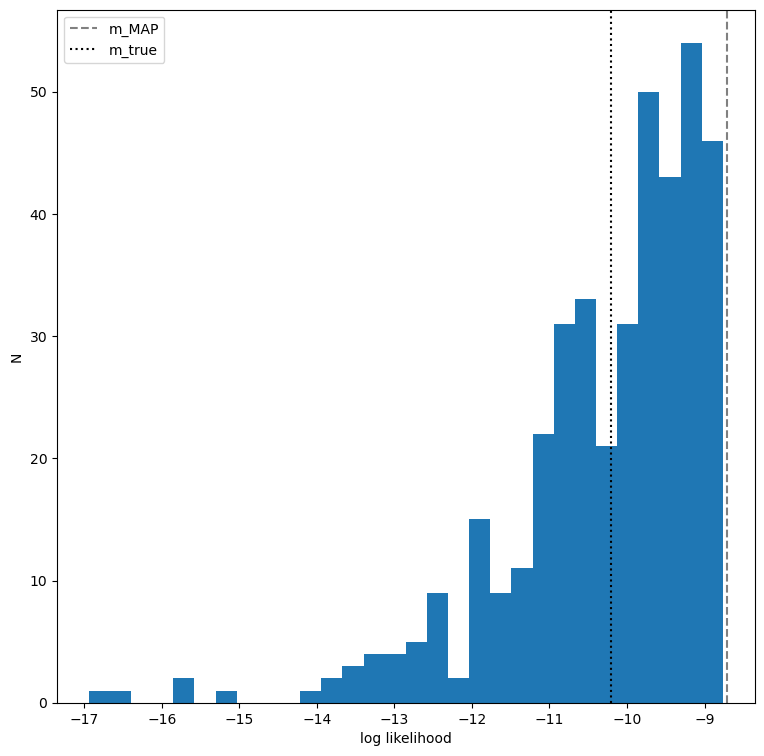

In [18]:
# %% Examine the likelihood probability distribution
loglike = np.empty(m_reduced.shape[1])
for i in range(m_reduced.shape[1]):
    loglike[i] = loglikelihood(m=m_reduced[:, i], x=x, y=y, sigma=sigma) + logprior(
        m=m_reduced[:, i], m_bounds=m_boundaries
    )

m_MAP_likelihood = loglikelihood(m_MAP, x=x, y=y, sigma=sigma) + logprior(
    m_MAP, m_bounds=m_boundaries
)
m_true_likelihood = loglikelihood(true_model, x=x, y=y, sigma=sigma) + logprior(
    true_model, m_bounds=m_boundaries
)

fig, ax = plt.subplots(1, 1, figsize=(9, 9))
plt.hist(loglike, bins=30)
ax.axvline(m_MAP_likelihood, color="grey", linestyle="--", label="m_MAP")
ax.axvline(m_true_likelihood, color="black", linestyle=":", label="m_true")
ax.set_xlabel("log likelihood")
ax.set_ylabel("N")
plt.legend()
plt.show()

Ellipsis

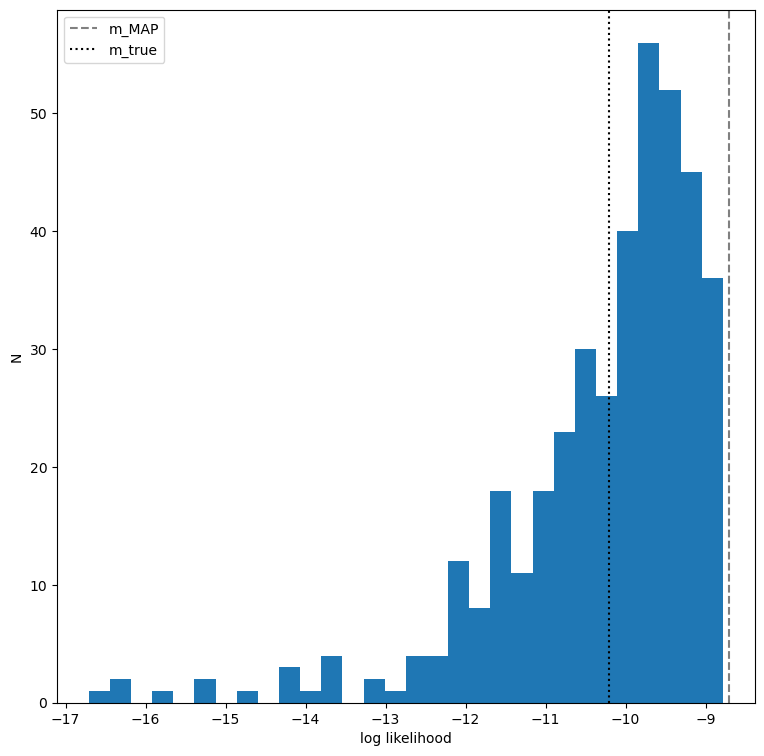

In [19]:
result.plot_likelihood_pdf()
...

In [20]:
# % Some simple experiments
# (b) Increase the amplitude of the data noise by a factor of 5.
# What effect does this have on the solution?

noisier_scale = 5 * noise_scale  # 0.05
noisier_sigma = noisier_scale * np.ones(y_true.size)
y_noisier = y_true + noisier_sigma * np.random.randn(y_true.size)

experiment_noisier = Experiment(x=x, y=y_noisier, sigma=noisier_sigma, m_boundaries=m_boundaries, step=step, true_model=true_model)
result_noisier = experiment_noisier.run(m0=m0, N=N, N_burn_in=burn_in, reducer=slice(None, None, skip))

  0%|          | 0/409999 [00:00<?, ?it/s]

Acceptance rate, P_acc = 0.834639024390244
MAP model:   [ 1.01645011 -0.98931679  1.60854805 -0.76536323]


MAP model:   [ 1.01645011 -0.98931679  1.60854805 -0.76536323] 
True model:  [1.0, -0.5, 1.0, -0.75]
Acceptance rate, P_acc = 0.834639024390244
95% confidence interval for m_1 is [0.50, 1.51]
95% confidence interval for m_2 is [-0.97, -0.37]
95% confidence interval for m_3 is [0.55, 1.91]
95% confidence interval for m_4 is [-0.94, -0.68]


Ellipsis

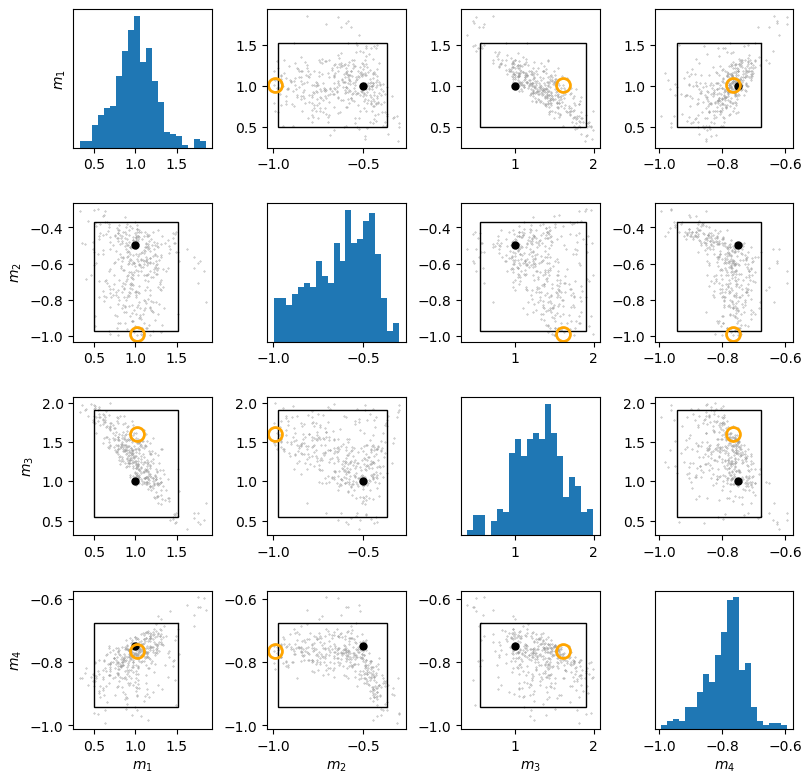

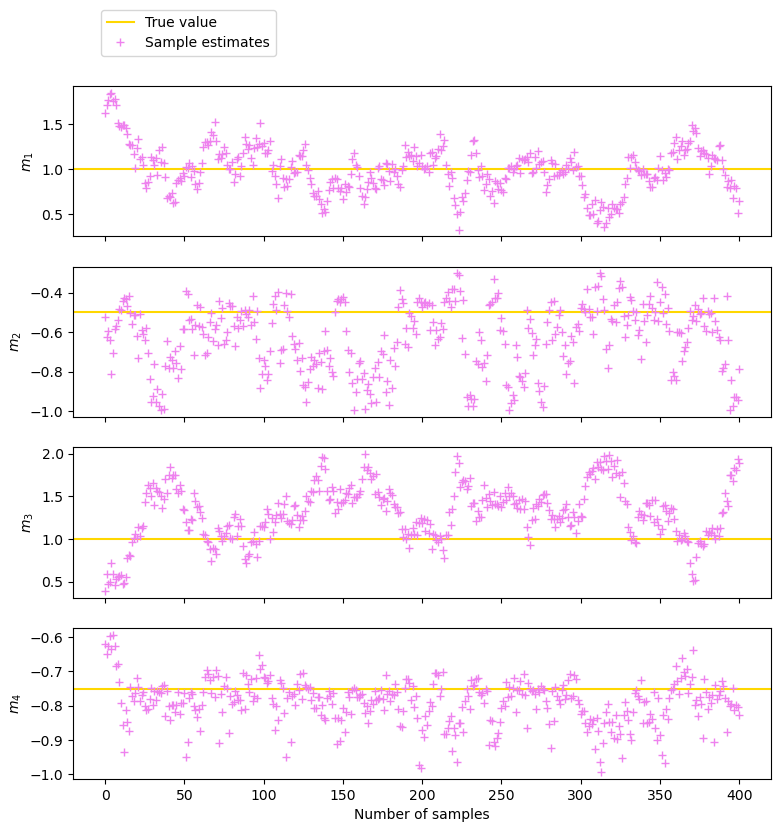

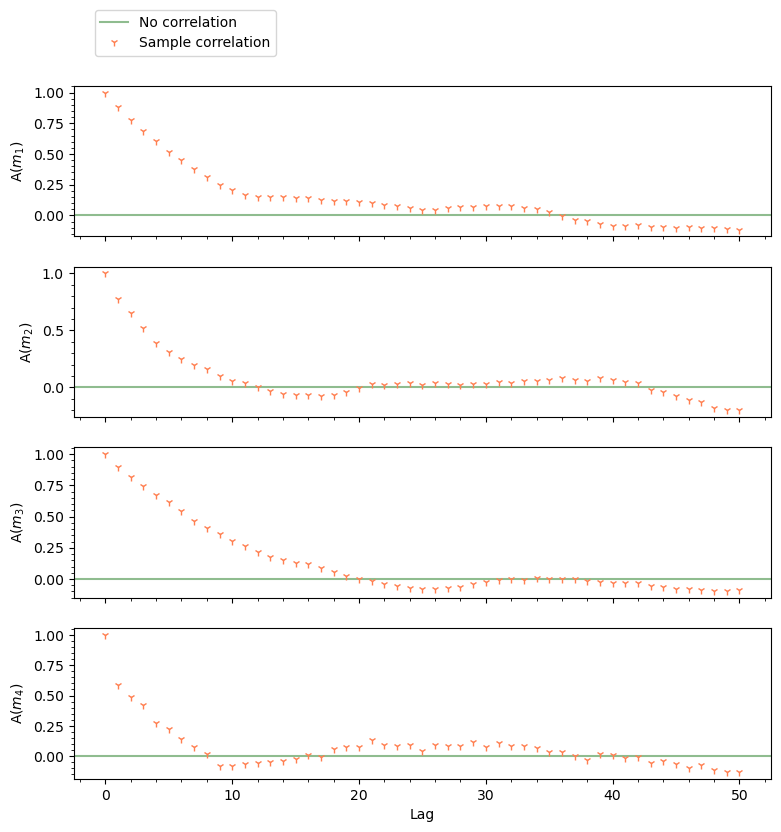

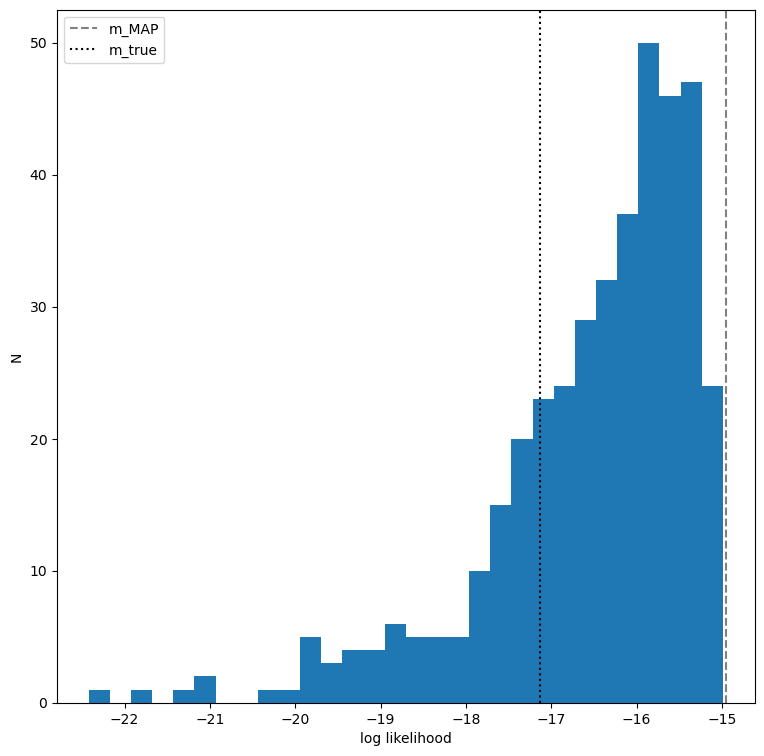

In [21]:
result_noisier.print_summary()
result_noisier.plot_results()
result_noisier.plot_history()
result_noisier.plot_autocorrelation()
result_noisier.plot_likelihood_pdf()
...

## (b) What happens when you increase the noise by a factor of 5?
- Looks like maybe longer decorrelation time?
- Likelihood has broader distribution
- Very large acceptance rate, probably does not explore sufficiently, which also explains longer characteristic correlation time

In [22]:
# (c) What happens if you then also increase the step by a factor 5?

scale_c = 5 * noise_scale  # 0.05
sigma_c = scale_c * np.ones(y_true.size)
y_c = y_true + sigma_c * np.random.randn(y_true.size)

step_c = 5 * step

experiment_c = Experiment(x=x, y=y_c, sigma=sigma_c, m_boundaries=m_boundaries, step=step_c, true_model=true_model)
result_c = experiment_c.run(m0=m0, N=N, N_burn_in=burn_in, reducer=slice(None, None, skip))

  0%|          | 0/409999 [00:00<?, ?it/s]

Acceptance rate, P_acc = 0.39869756097560977
MAP model:   [ 0.4101663  -0.28210669  1.76282685 -0.92587596]


MAP model:   [ 0.4101663  -0.28210669  1.76282685 -0.92587596] 
True model:  [1.0, -0.5, 1.0, -0.75]
Acceptance rate, P_acc = 0.39869756097560977
95% confidence interval for m_1 is [0.28, 1.51]
95% confidence interval for m_2 is [-0.96, -0.26]
95% confidence interval for m_3 is [0.45, 1.90]
95% confidence interval for m_4 is [-0.98, -0.63]


Ellipsis

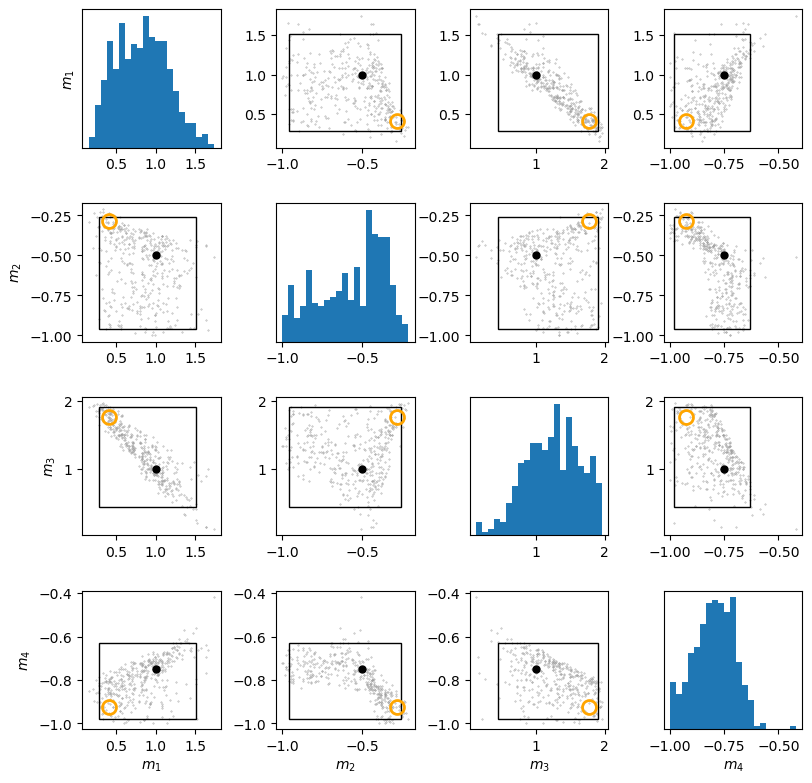

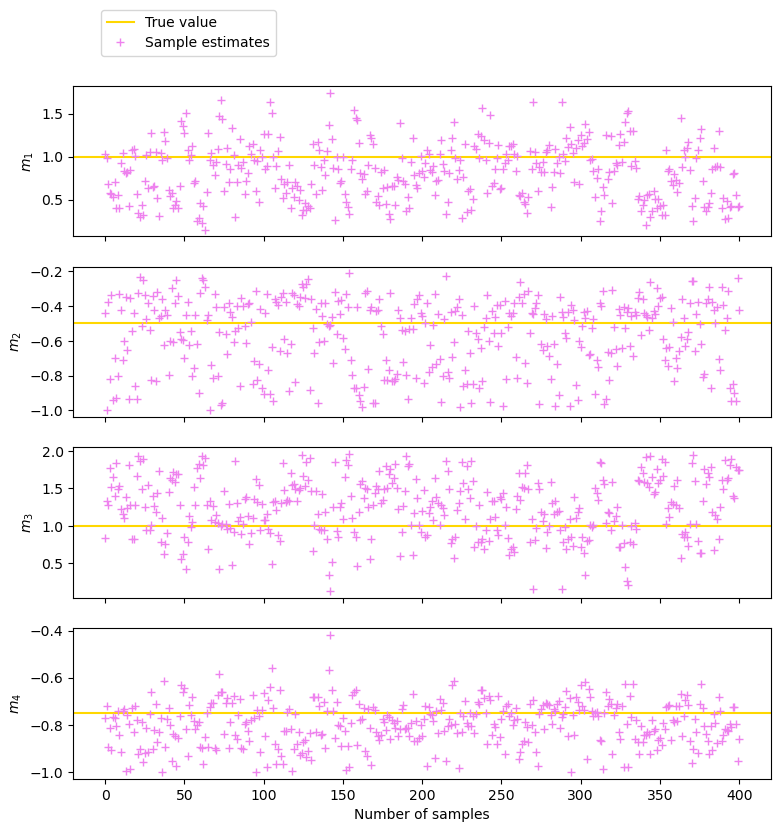

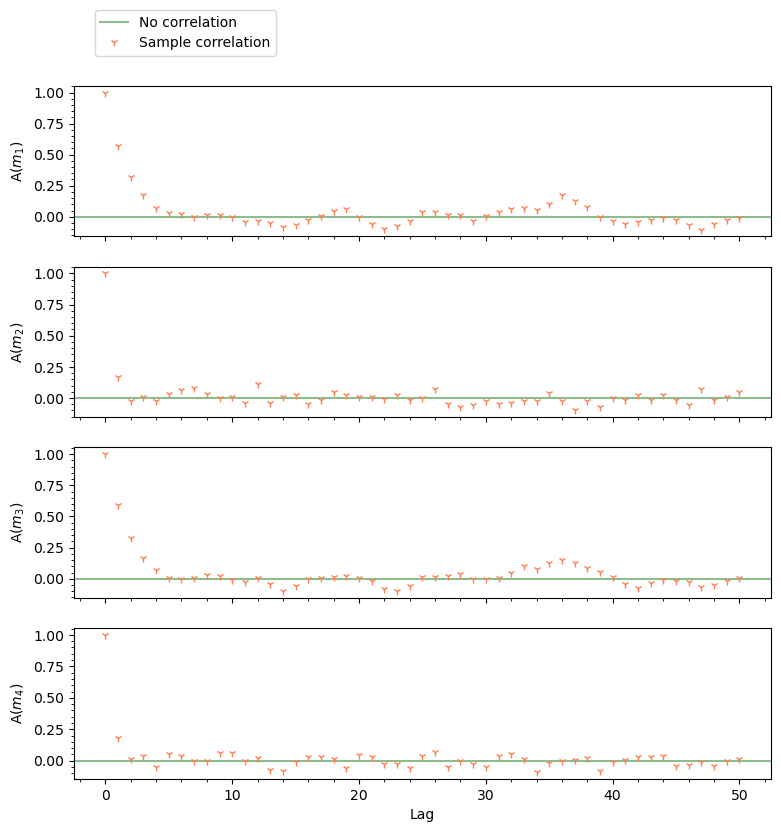

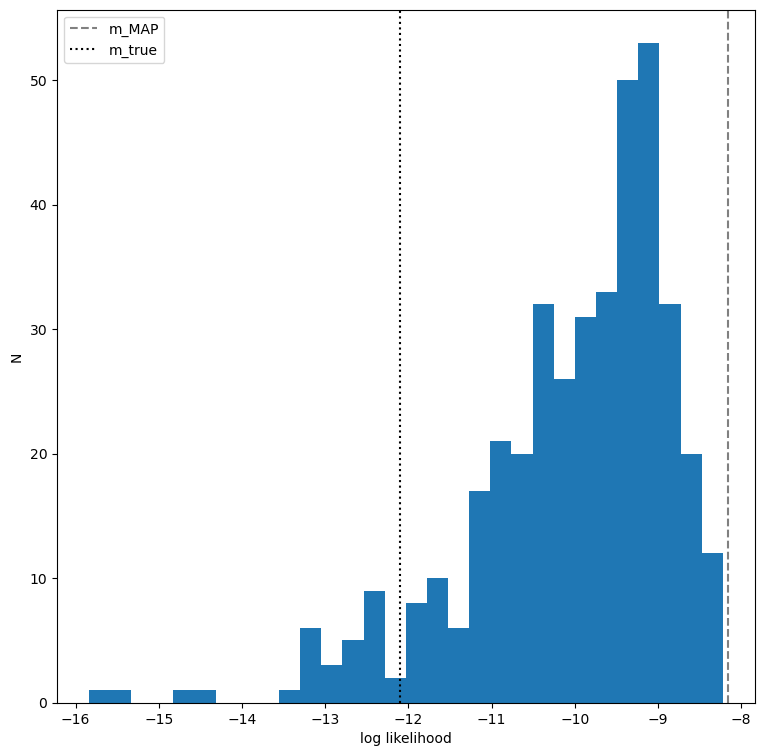

In [23]:
result_c.print_summary()
result_c.plot_results()
result_c.plot_history()
result_c.plot_autocorrelation()
result_c.plot_likelihood_pdf()
...

## (c) What happens if you then also increase the step by a factor 5?

- Much shorter correlation times
- Likelihood less skewed
- Uncertainty remains elevated

In [24]:

# (d) going back to the original problem, what happens if you increase
# the size of the interval of the uniform prior by a factor of 2 (leave one boundary at zero and change the other)?

m_boundaries_d = np.array([[0, 4.0], [-2.0, 0], [0, 4.0], [-2.0, 0]])
experiment_d = Experiment(x=x, y=y, sigma=sigma, m_boundaries=m_boundaries_d, step=step, true_model=true_model)
result_d = experiment_d.run(m0=m0, N=N, N_burn_in=burn_in, reducer=slice(None, None, skip))

  0%|          | 0/409999 [00:00<?, ?it/s]

Acceptance rate, P_acc = 0.3866390243902439
MAP model:   [ 0.98412838 -0.55919113  1.04284953 -0.72078848]


MAP model:   [ 0.98412838 -0.55919113  1.04284953 -0.72078848] 
True model:  [1.0, -0.5, 1.0, -0.75]
Acceptance rate, P_acc = 0.3866390243902439
95% confidence interval for m_1 is [0.82, 1.73]
95% confidence interval for m_2 is [-1.87, -0.43]
95% confidence interval for m_3 is [0.92, 1.75]
95% confidence interval for m_4 is [-0.80, -0.69]


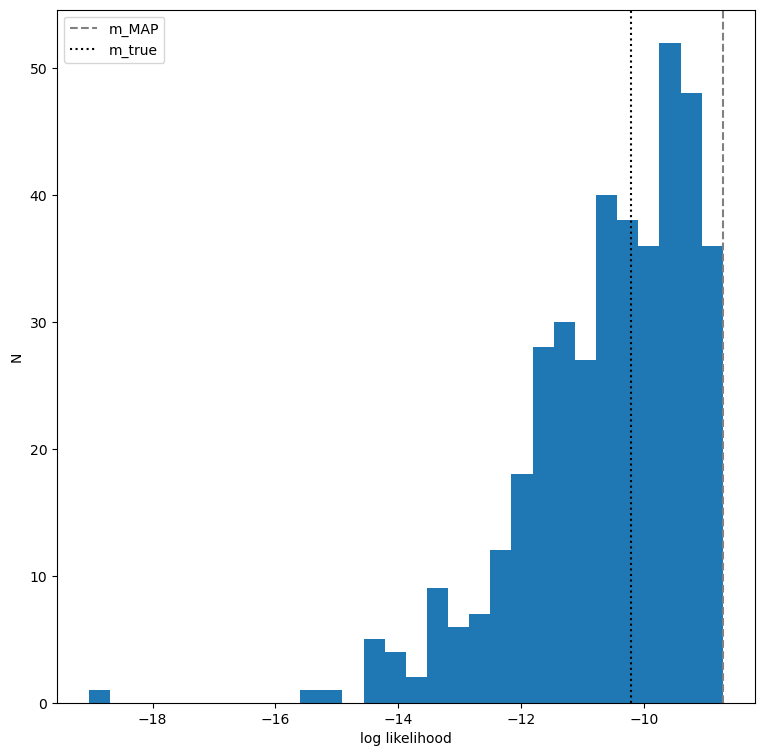

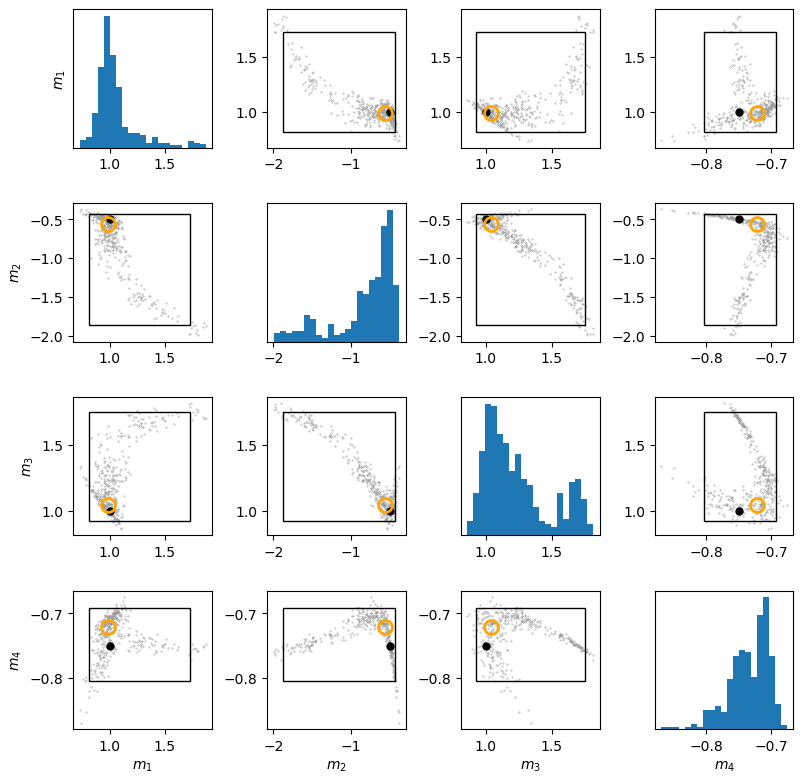

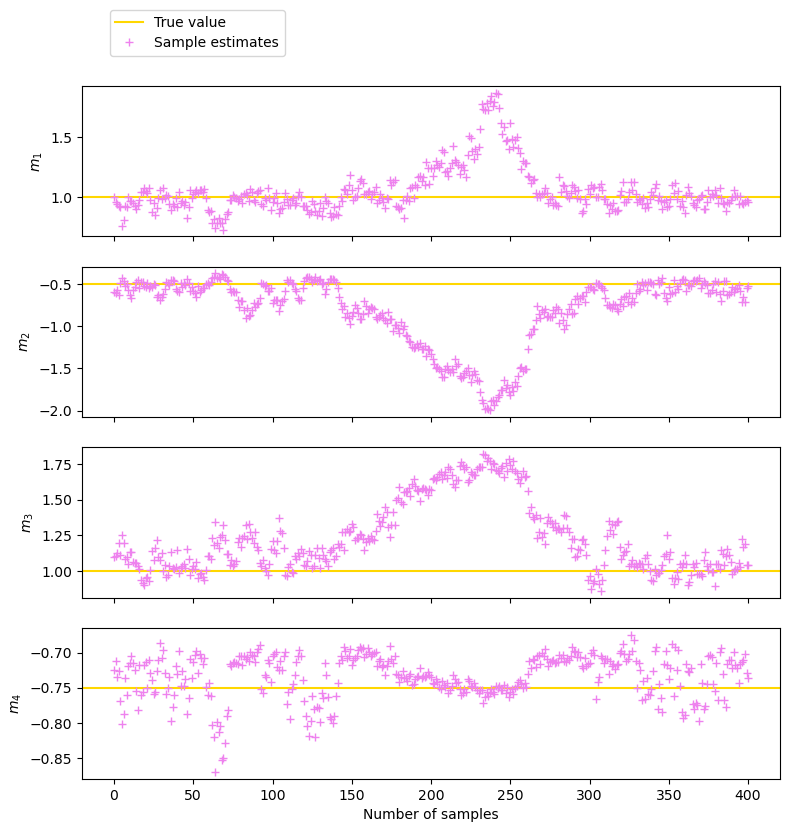

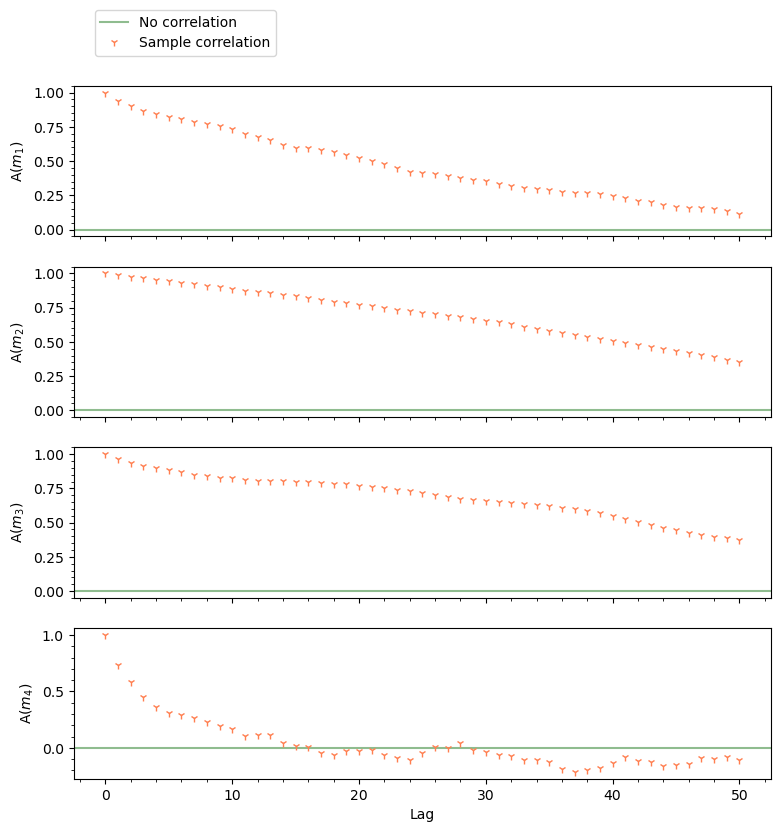

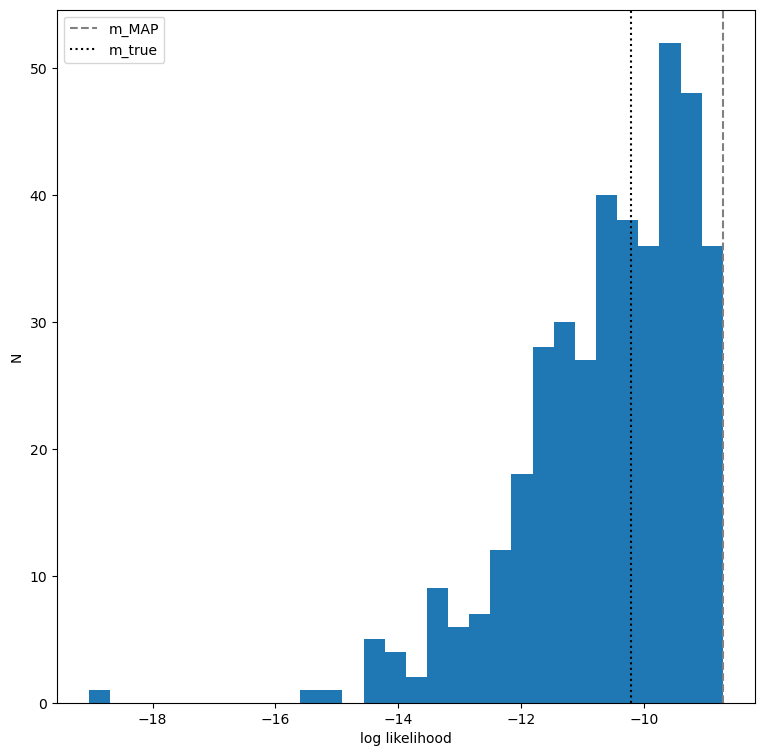

In [25]:
result_d.print_summary()
result_d.plot_results()
result_d.plot_history()
result_d.plot_autocorrelation()
result_d.plot_likelihood_pdf()

## (d) going back to the original problem, what happens if you increase the size of the interval of the uniform prior by a factor of 2 (leave one boundary at zero and change the other)?

- Correlation times go way up (still okay, we do skip=1000, and correlation time still seems to be ~100)
- Burn-in period is not long enough anymore though


In [26]:

# (e) What is the consequence of having a poor starting guess?
# e.g. for the larger prior of (d) interval try
# m0=[3.5; -1.5; 3.5; -1.8];

m0_e = np.array([3.5, -1.5, 3.5, -1.8])
experiment_e = Experiment(x=x, y=y, sigma=sigma, m_boundaries=m_boundaries_d, step=step, true_model=true_model)
result_e = experiment_e.run(m0=m0_e, N=N, N_burn_in=burn_in, reducer=slice(None, None, skip))


  0%|          | 0/409999 [00:00<?, ?it/s]

Acceptance rate, P_acc = 0.37281951219512194
MAP model:   [ 0.98657854 -0.56534733  1.04702115 -0.71951898]


MAP model:   [ 0.98657854 -0.56534733  1.04702115 -0.71951898] 
True model:  [1.0, -0.5, 1.0, -0.75]
Acceptance rate, P_acc = 0.37281951219512194
95% confidence interval for m_1 is [0.85, 1.62]
95% confidence interval for m_2 is [-1.82, -0.45]
95% confidence interval for m_3 is [0.94, 1.74]
95% confidence interval for m_4 is [-0.78, -0.69]


Ellipsis

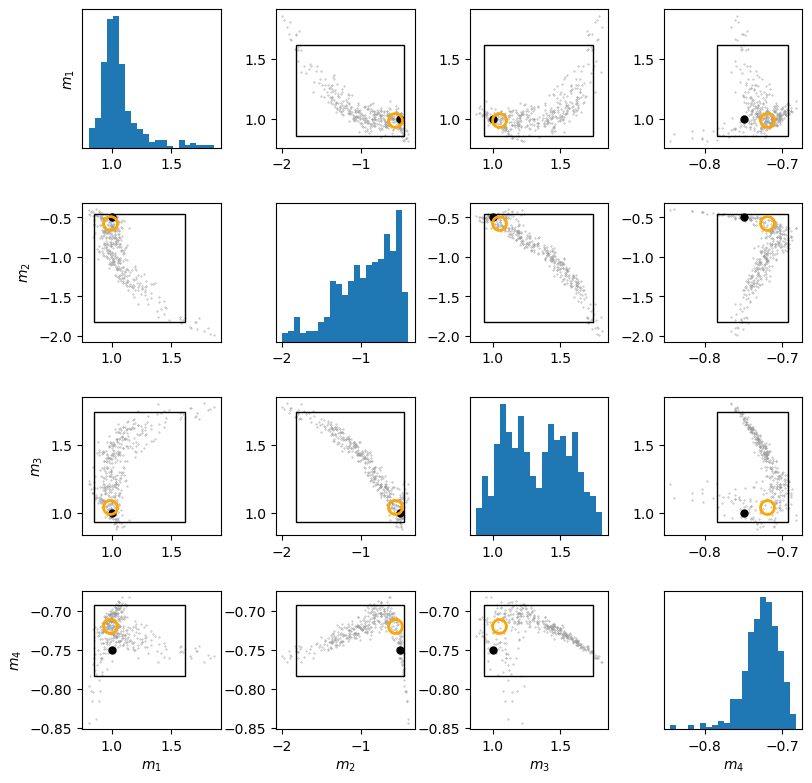

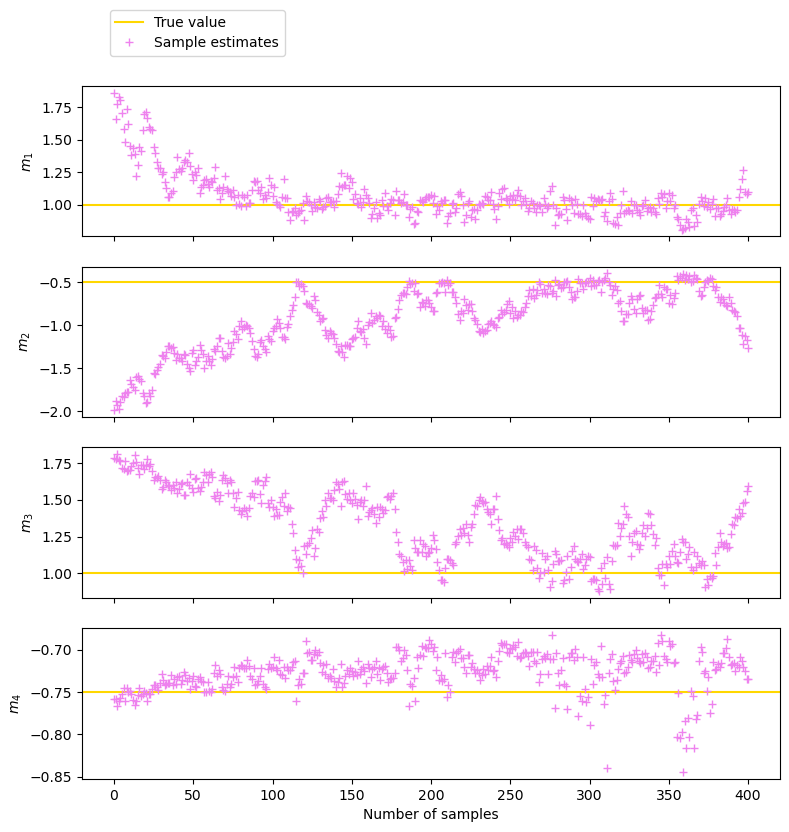

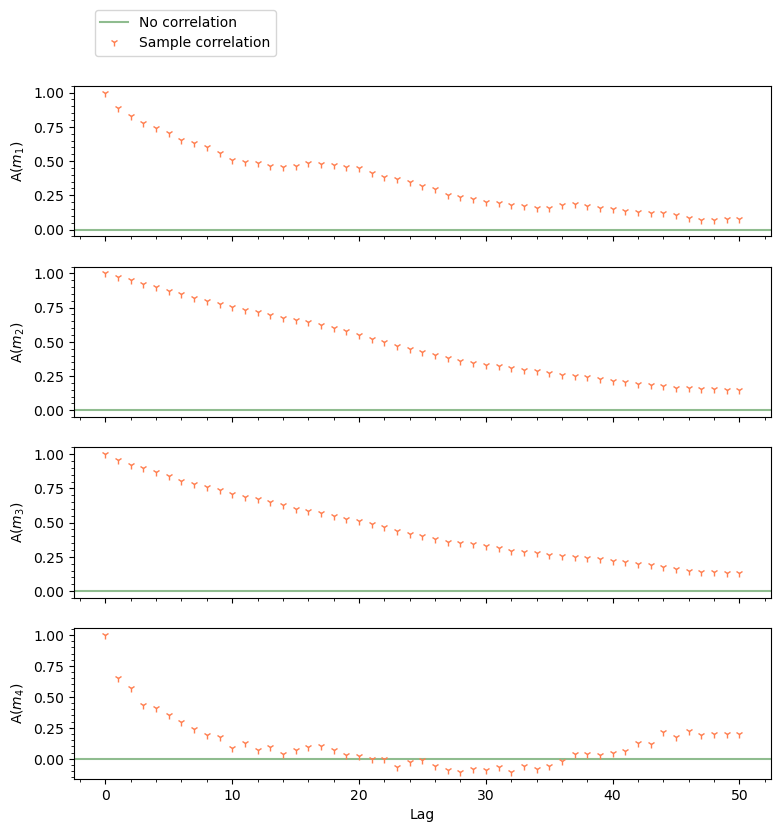

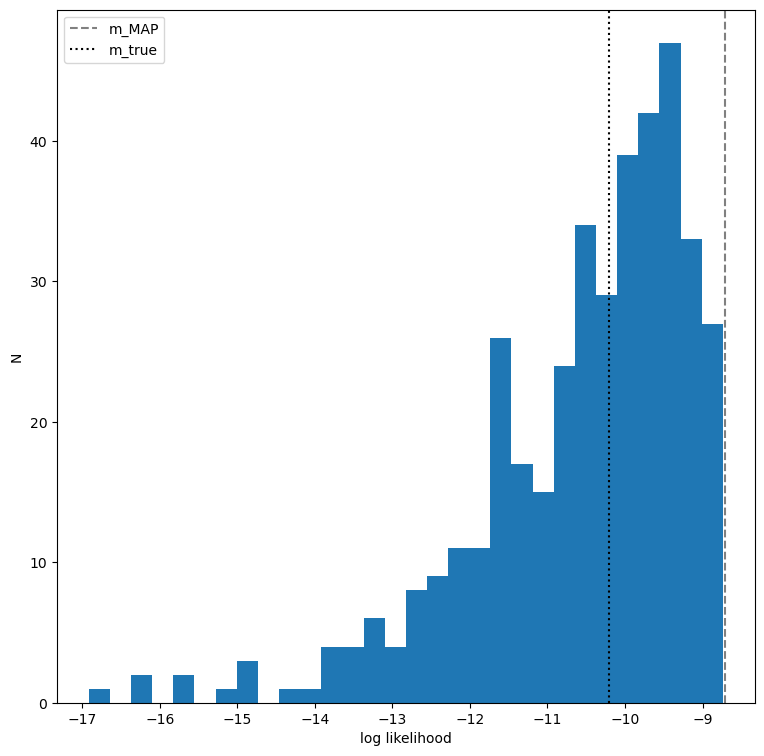

In [27]:
result_e.print_summary()
result_e.plot_results()
result_e.plot_history()
result_e.plot_autocorrelation()
result_e.plot_likelihood_pdf()
...


# (e) What is the consequence of having a poor starting guess?
# e.g. for the larger prior of (d) interval try
# m0=[3.5; -1.5; 3.5; -1.8];

Again, some parameters are way off in the starting guess, so much larger burn-in is required.

Q: Is it a good idea to maybe have larger step size during burn-in?

Currently much of the captured data is still a result of the transient from the bad initial guess